DV - Optimizing IT Support Team Performance Using Analytics ( Supportlytics)

                                  **Milestone** 1

Module 1:- Project Initialization and Dataset Setup • Define objectives, KPIs, and workflow • Load the CSV dataset using pandas • Explore schema, data types, and missing values • Calculate initial ticket distribution by Type, Priority, and Category

In [1]:
[]
import pandas as pd
from google.colab import files

In [2]:
from google.colab import files
uploaded = files.upload()


Saving customer_support_insights_10k.csv.xlsx to customer_support_insights_10k.csv (1).xlsx


In [3]:
import pandas as pd
df = pd.read_excel("customer_support_insights_10k.csv.xlsx")

In [4]:
df.shape

(10000, 30)

In [5]:
df.columns

Index(['Ticket_ID', 'Created_Date', 'Resolution_Date', 'Status', 'Priority',
       'Ticket_Type', 'Category', 'Country', 'Cluster_ID', 'Cluster_Name',
       'Similarity_Score', 'Similarity_Level', 'First_Response_Date',
       'Assigned_Agent', 'Team', 'SLA_Status', 'Reopened', 'Resolution_Code',
       'Department', 'Customer_ID', 'Channel', 'Description', 'Tags',
       'Product', 'Customer_Satisfaction', 'Escalation_Level', 'Region',
       'Device_Type', 'Operating_System', 'Resolution_Notes'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Ticket_ID              10000 non-null  object 
 1   Created_Date           10000 non-null  object 
 2   Resolution_Date        10000 non-null  object 
 3   Status                 10000 non-null  object 
 4   Priority               10000 non-null  object 
 5   Ticket_Type            10000 non-null  object 
 6   Category               10000 non-null  object 
 7   Country                10000 non-null  object 
 8   Cluster_ID             10000 non-null  int64  
 9   Cluster_Name           10000 non-null  object 
 10  Similarity_Score       10000 non-null  float64
 11  Similarity_Level       10000 non-null  object 
 12  First_Response_Date    10000 non-null  object 
 13  Assigned_Agent         10000 non-null  object 
 14  Team                   10000 non-null  object 
 15  SLA

In [8]:
df.describe()

,Cluster_ID,Similarity_Score,Customer_Satisfaction
count,10000.00000,10000.000000,9045.000000
mean,4.02590,0.771893,4.146932
std,2.00555,0.127111,1.093168
min,1.00000,0.550000,1.000000
25%,2.00000,0.660000,4.000000
50%,4.00000,0.770000,5.000000
75%,6.00000,0.880000,5.000000
max,7.00000,0.990000,5.000000


In [9]:
df.head()

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Channel,Description,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes
0,TKT-100000,2026-04-30 08:26:00,2026-05-02 00:26:00,Pending,Critical,Incident,Technical,Germany,6,UI/UX & Display Bugs,...,Chat,Buttons overlapping,tag_technical;issue,SaaS Dashboard Pro,NaN,Level 2,EMEA,Generic Workstation,iOS 17,Issue resolved using standard protocol for Sol...
1,TKT-100001,2026-01-24 07:42:00,2026-01-26 05:42:00,Pending,Low,Question,Billing,Japan,5,Account Security,...,Mobile App,Change registered email,tag_billing;issue,Enterprise Plugin,NaN,Level 0,APAC,Generic Workstation,macOS Sonoma,Issue resolved using standard protocol for Dup...
2,TKT-100002,2026-02-28 21:37:00,2026-03-03 16:37:00,Closed,Medium,Question,Technical,India,6,UI/UX & Display Bugs,...,Email,Font too small,tag_technical;issue,Mobile App Basic,5.0,Level 0,APAC,Laptop,macOS Sonoma,Issue resolved using standard protocol for Wor...
3,TKT-100003,2026-03-20 05:25:00,2026-03-21 08:25:00,Resolved,Low,Incident,Billing,United States,7,Hardware & Device Sync,...,Email,Bluetooth sync error,tag_billing;issue,SaaS Dashboard Pro,3.0,Level 0,AMER,iPhone,iOS 17,Issue resolved using standard protocol for Sol...
4,TKT-100004,2026-02-23 10:28:00,2026-02-24 13:28:00,Closed,Low,Feature Request,Billing,Japan,6,UI/UX & Display Bugs,...,Chat,Dark mode not working,tag_billing;issue,Enterprise Plugin,3.0,Level 0,APAC,Desktop,macOS Sonoma,Issue resolved using standard protocol for Sol...


In [10]:
df.isnull().sum()

,0
Ticket_ID,0
Created_Date,0
Resolution_Date,0
Status,0
Priority,0
Ticket_Type,0
Category,0
Country,0
Cluster_ID,0
Cluster_Name,0


In [11]:
df.dtypes

,0
Ticket_ID,object
Created_Date,object
Resolution_Date,object
Status,object
Priority,object
Ticket_Type,object
Category,object
Country,object
Cluster_ID,int64
Cluster_Name,object


In [12]:
df['Ticket_Type'].value_counts()

,count
Ticket_Type,
Incident,5532
Question,1964
Problem,1546
Feature Request,958


In [13]:
df['Priority'].value_counts()

,count
Priority,
Medium,3893
Low,3550
High,1846
Critical,711


In [14]:
df['Category'].value_counts()

,count
Category,
Technical,4426
Billing,2549
Account Management,2065
General Inquiry,960


In [15]:
df.isnull().sum()

,0
Ticket_ID,0
Created_Date,0
Resolution_Date,0
Status,0
Priority,0
Ticket_Type,0
Category,0
Country,0
Cluster_ID,0
Cluster_Name,0


Module 2:- Data Cleaning and Feature Engineering • Handle missing or incorrect data in text fields • Create new features: Resolution_Duration and Priority_Score • Save processed data for analysis • Deliverables: Cleaned dataset, Feature engineering summary, Data dictionary

In [16]:
missing = df.isnull().sum()
missing[missing > 0]

,0
Customer_Satisfaction,955


In [17]:
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    print(col)
    print((df[col].str.strip() == "").sum())

Ticket_ID
0
Created_Date
0
Resolution_Date
0
Status
0
Priority
0
Ticket_Type
0
Category
0
Country
0
Cluster_Name
0
Similarity_Level
0
First_Response_Date
0
Assigned_Agent
0
Team
0
SLA_Status
0
Reopened
0
Resolution_Code
0
Department
0
Customer_ID
0
Channel
0
Description
0
Tags
0
Product
0
Escalation_Level
0
Region
0
Device_Type
0
Operating_System
0
Resolution_Notes
0


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
for col in text_columns:
    df[col] = df[col].str.strip()

In [20]:
df['Created_Date'] = pd.to_datetime(df['Created_Date'])
df['Resolution_Date'] = pd.to_datetime(df['Resolution_Date'])

df['Resolution_Duration'] = (
    df['Resolution_Date'] - df['Created_Date']
).dt.days

df[['Created_Date', 'Resolution_Date', 'Resolution_Duration']].head()

,Created_Date,Resolution_Date,Resolution_Duration
0,2026-04-30 08:26:00,2026-05-02 00:26:00,1
1,2026-01-24 07:42:00,2026-01-26 05:42:00,1
2,2026-02-28 21:37:00,2026-03-03 16:37:00,2
3,2026-03-20 05:25:00,2026-03-21 08:25:00,1
4,2026-02-23 10:28:00,2026-02-24 13:28:00,1


In [21]:
priority_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3,
    'Critical': 4
}

df['Priority_Score'] = df['Priority'].map(priority_map)
df[['Priority', 'Priority_Score']].head()

,Priority,Priority_Score
0,Critical,4
1,Low,1
2,Medium,2
3,Low,1
4,Low,1


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Ticket_ID              10000 non-null  object        
 1   Created_Date           10000 non-null  datetime64[ns]
 2   Resolution_Date        10000 non-null  datetime64[ns]
 3   Status                 10000 non-null  object        
 4   Priority               10000 non-null  object        
 5   Ticket_Type            10000 non-null  object        
 6   Category               10000 non-null  object        
 7   Country                10000 non-null  object        
 8   Cluster_ID             10000 non-null  int64         
 9   Cluster_Name           10000 non-null  object        
 10  Similarity_Score       10000 non-null  float64       
 11  Similarity_Level       10000 non-null  object        
 12  First_Response_Date    10000 non-null  object        
 13  As

In [23]:
df.to_csv("customer_support_processed.csv", index=False)

                                          **Milestone** 2

Module 3: – Exploratory Visualization • Plot ticket type distribution • Identify top categories and clusters by frequency • Visualize tickets by priority and queue

In [24]:
df

,Ticket_ID,Created_Date,Resolution_Date,Status,Priority,Ticket_Type,Category,Country,Cluster_ID,Cluster_Name,...,Tags,Product,Customer_Satisfaction,Escalation_Level,Region,Device_Type,Operating_System,Resolution_Notes,Resolution_Duration,Priority_Score
0,TKT-100000,2026-04-30 08:26:00,2026-05-02 00:26:00,Pending,Critical,Incident,Technical,Germany,6,UI/UX & Display Bugs,...,tag_technical;issue,SaaS Dashboard Pro,NaN,Level 2,EMEA,Generic Workstation,iOS 17,Issue resolved using standard protocol for Sol...,1,4
1,TKT-100001,2026-01-24 07:42:00,2026-01-26 05:42:00,Pending,Low,Question,Billing,Japan,5,Account Security,...,tag_billing;issue,Enterprise Plugin,NaN,Level 0,APAC,Generic Workstation,macOS Sonoma,Issue resolved using standard protocol for Dup...,1,1
2,TKT-100002,2026-02-28 21:37:00,2026-03-03 16:37:00,Closed,Medium,Question,Technical,India,6,UI/UX & Display Bugs,...,tag_technical;issue,Mobile App Basic,5.0,Level 0,APAC,Laptop,macOS Sonoma,Issue resolved using standard protocol for Wor...,2,2
3,TKT-100003,2026-03-20 05:25:00,2026-03-21 08:25:00,Resolved,Low,Incident,Billing,United States,7,Hardware & Device Sync,...,tag_billing;issue,SaaS Dashboard Pro,3.0,Level 0,AMER,iPhone,iOS 17,Issue resolved using standard protocol for Sol...,1,1
4,TKT-100004,2026-02-23 10:28:00,2026-02-24 13:28:00,Closed,Low,Feature Request,Billing,Japan,6,UI/UX & Display Bugs,...,tag_billing;issue,Enterprise Plugin,3.0,Level 0,APAC,Desktop,macOS Sonoma,Issue resolved using standard protocol for Sol...,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,TKT-109995,2026-04-22 18:35:00,2026-04-23 21:35:00,Closed,Low,Question,Technical,France,6,UI/UX & Display Bugs,...,tag_technical;issue,SaaS Dashboard Pro,5.0,Level 0,EMEA,iPhone,macOS Sonoma,Issue resolved using standard protocol for Bug...,1,1
9996,TKT-109996,2026-02-04 10:23:00,2026-02-04 11:23:00,Resolved,Low,Incident,Billing,Japan,7,Hardware & Device Sync,...,tag_billing;issue,Mobile App Basic,4.0,Level 0,APAC,iPhone,iOS 17,Issue resolved using standard protocol for Ref...,0,1
9997,TKT-109997,2026-04-23 04:54:00,2026-04-25 16:54:00,Closed,Medium,Incident,Billing,India,4,Subscription & Refunds,...,tag_billing;issue,Enterprise Plugin,5.0,Level 0,APAC,Generic Workstation,iOS 17,Issue resolved using standard protocol for Wor...,2,2
9998,TKT-109998,2026-01-29 08:00:00,2026-02-01 16:00:00,Resolved,High,Question,Technical,Australia,2,Billing & Invoices,...,tag_technical;issue,SaaS Dashboard Pro,5.0,Level 1,APAC,Desktop,macOS Sonoma,Issue resolved using standard protocol for Bug...,3,3


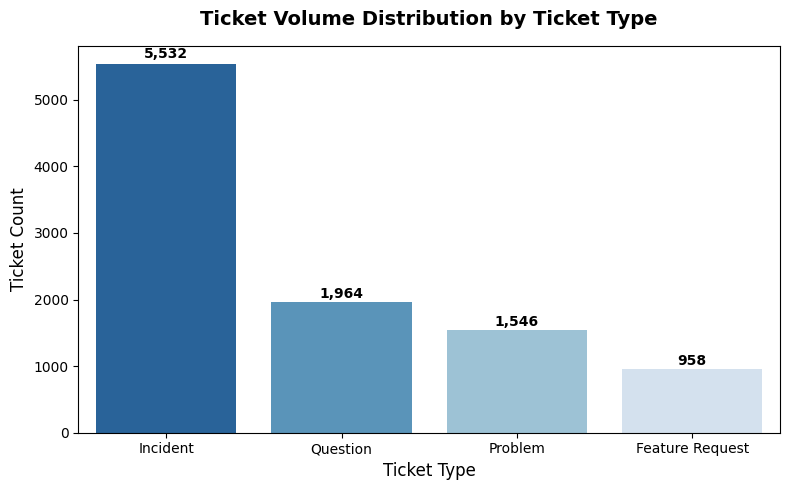

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- CELL 1: TICKET TYPE DISTRIBUTION ---
plt.figure(figsize=(8, 5))
type_counts = df['Ticket_Type'].value_counts()

sns.barplot(
    x=type_counts.index,
    y=type_counts.values,
    palette='Blues_r',
    hue=type_counts.index,
    legend=False
)
plt.title('Ticket Volume Distribution by Ticket Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Ticket Type', fontsize=12)
plt.ylabel('Ticket Count', fontsize=12)

# Add data labels on top of the bars
for i, val in enumerate(type_counts.values):
    plt.text(i, val + (val * 0.01), f"{val:,}", ha='center', va='bottom', fontweight='semibold')

plt.tight_layout()
plt.show()

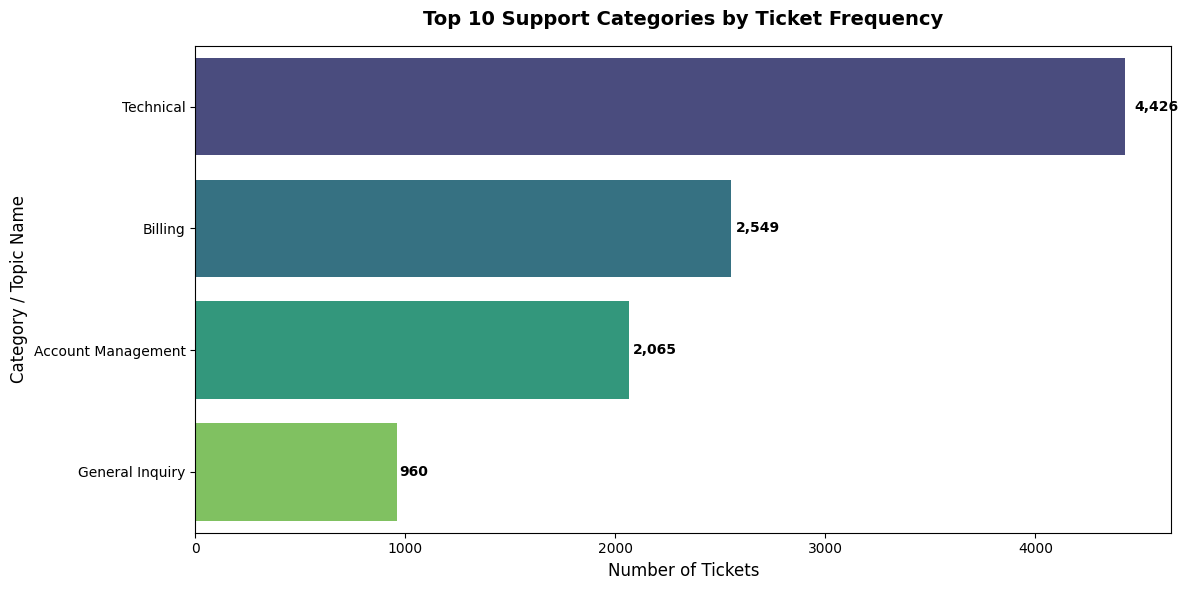

In [26]:
# --- CELL 2: TOP CATEGORIES BY FREQUENCY ---
top_categories = df['Category'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(
    y=top_categories.index,
    x=top_categories.values,
    palette='viridis',
    hue=top_categories.index,
    legend=False
)
plt.title('Top 10 Support Categories by Ticket Frequency', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Tickets', fontsize=12)
plt.ylabel('Category / Topic Name', fontsize=12)

# Add data labels next to the horizontal bars
for i, val in enumerate(top_categories.values):
    plt.text(val + (val * 0.01), i, f"{val:,}", ha='left', va='center', fontweight='semibold')

plt.tight_layout()
plt.show()

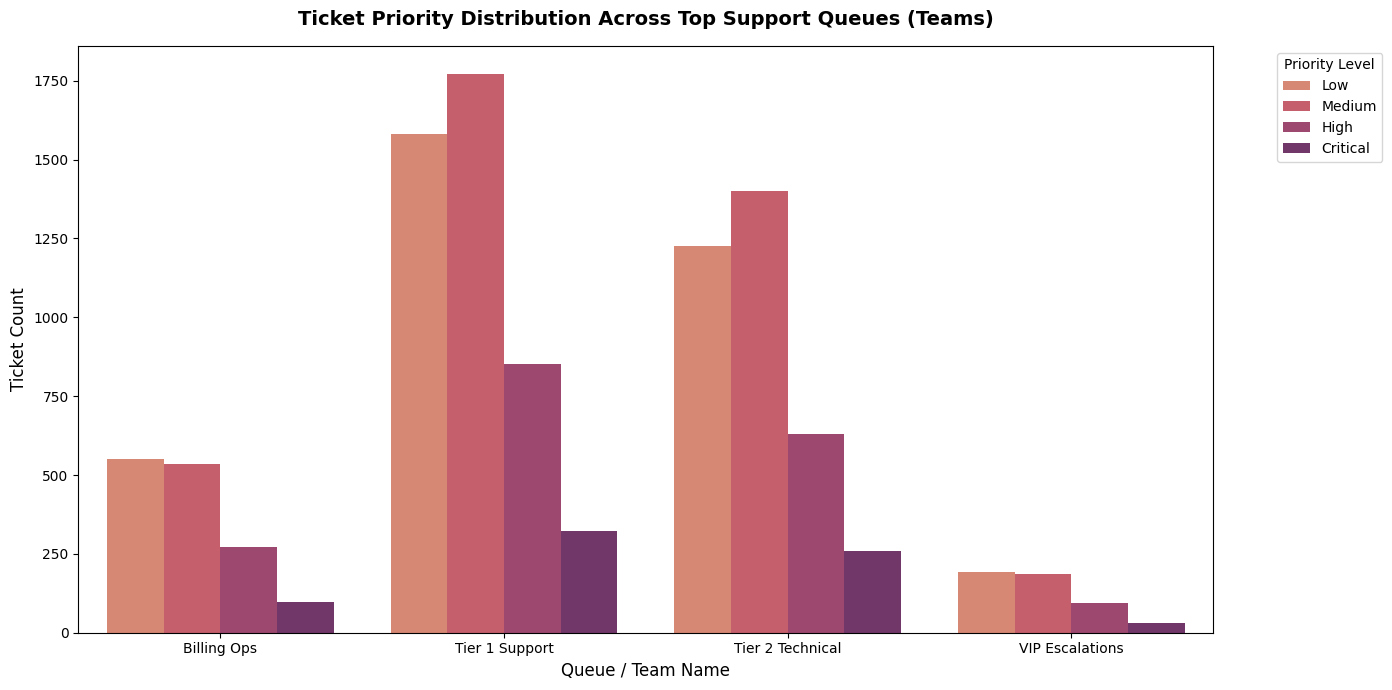

In [27]:
# --- CELL 3: TICKETS BY PRIORITY AND QUEUE ---
# Check if your column is named 'Queue' or 'Team'
queue_col = 'Queue' if 'Queue' in df.columns else 'Team'

if queue_col in df.columns:
    # Filter to the top 5 busiest teams to keep the chart clean
    top_queues = df[queue_col].value_counts().head(5).index
    df_filtered_queues = df[df[queue_col].isin(top_queues)]

    plt.figure(figsize=(14, 7))
    sns.countplot(
        data=df_filtered_queues,
        x=queue_col,
        hue='Priority',
        hue_order=['Low', 'Medium', 'High', 'Critical'],
        palette='flare'
    )
    plt.title(f'Ticket Priority Distribution Across Top Support Queues ({queue_col}s)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Queue / Team Name', fontsize=12)
    plt.ylabel('Ticket Count', fontsize=12)
    plt.legend(title='Priority Level', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print(f"Skipping Queue Chart: Could not find a 'Queue' or 'Team' column in: {list(df.columns)}")

Module 4:- Similarity and Cluster Insights • Analyze average similarity scores within clusters • Compare cluster size vs. issue type • Visualize performance gaps using boxplots and scatter plots • Deliverables: Minimum 8 visualizations, Summary of key patterns and problem clusters

In [28]:
# --- STEP 1: CALCULATE DETAILED SIMILARITY METRICS ---
import pandas as pd

# Group by Cluster and calculate key statistical metrics
similarity_summary = df.groupby('Cluster_Name').agg(
    Ticket_Count=('Ticket_ID', 'count'),
    Average_Similarity=('Similarity_Score', 'mean'),
    Median_Similarity=('Similarity_Score', 'median'),
    Min_Similarity=('Similarity_Score', 'min'),
    Max_Similarity=('Similarity_Score', 'max')
).reset_index()

# Sort by Average Similarity (highest to lowest)
similarity_summary = similarity_summary.sort_values(by='Average_Similarity', ascending=False)

# Display the summary table
print("=== CLUSTER SIMILARITY ANALYSIS ===")
print(similarity_summary.to_string(index=False))

=== CLUSTER SIMILARITY ANALYSIS ===
           Cluster_Name  Ticket_Count  Average_Similarity  Median_Similarity  Min_Similarity  Max_Similarity
 Subscription & Refunds          1440            0.777653               0.78            0.55            0.99
Password & Login Issues          1420            0.773380               0.78            0.55            0.99
       Account Security          1475            0.773247               0.78            0.55            0.99
 Hardware & Device Sync          1481            0.772424               0.77            0.55            0.99
     Billing & Invoices          1418            0.769436               0.77            0.55            0.99
   UI/UX & Display Bugs          1401            0.769108               0.77            0.55            0.99
  App Performance/Crash          1365            0.767641               0.76            0.55            0.99


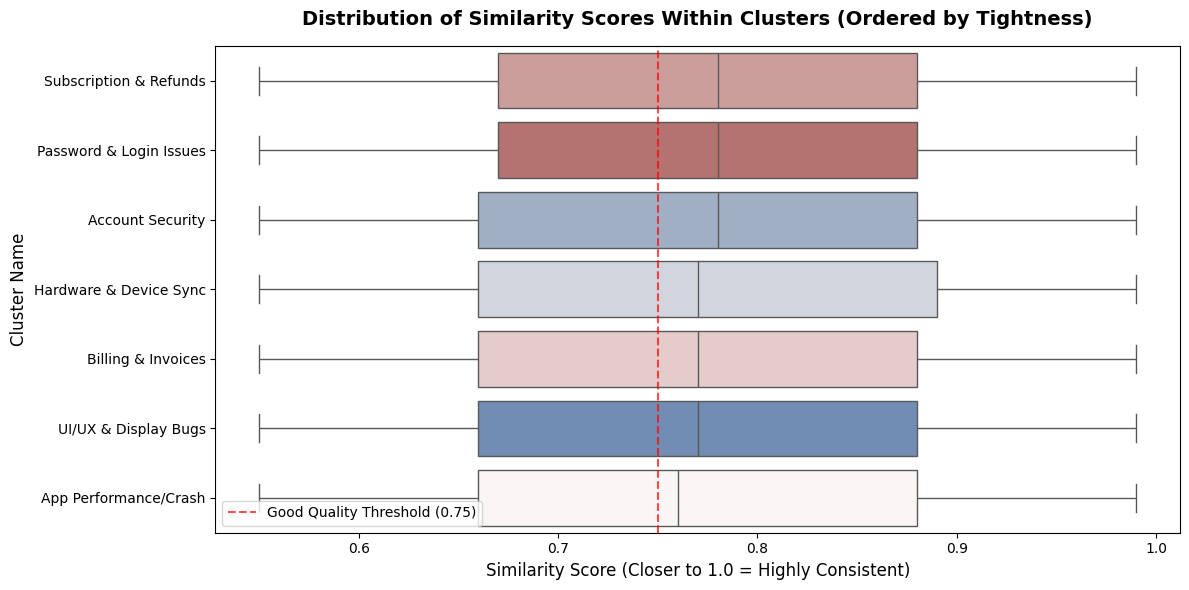

In [29]:
# --- STEP 2: PLOT SIMILARITY SPREAD BY CLUSTER ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Boxplot showing the exact distribution of similarity scores inside each cluster
sns.boxplot(
    data=df,
    y='Cluster_Name',
    x='Similarity_Score',
    palette='vlag',
    hue='Cluster_Name',
    legend=False,
    order=similarity_summary['Cluster_Name'] # Ordered from highest average similarity to lowest
)

plt.title('Distribution of Similarity Scores Within Clusters (Ordered by Tightness)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Similarity Score (Closer to 1.0 = Highly Consistent)', fontsize=12)
plt.ylabel('Cluster Name', fontsize=12)
plt.axvline(x=0.75, color='red', linestyle='--', alpha=0.7, label='Good Quality Threshold (0.75)')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

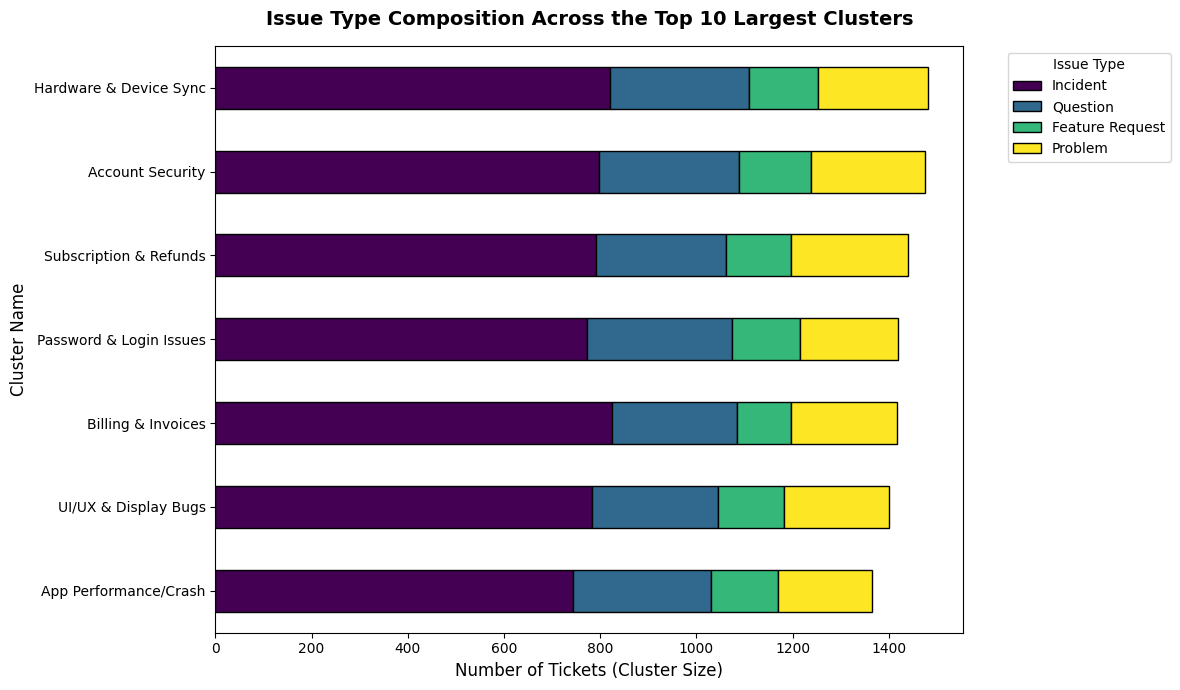

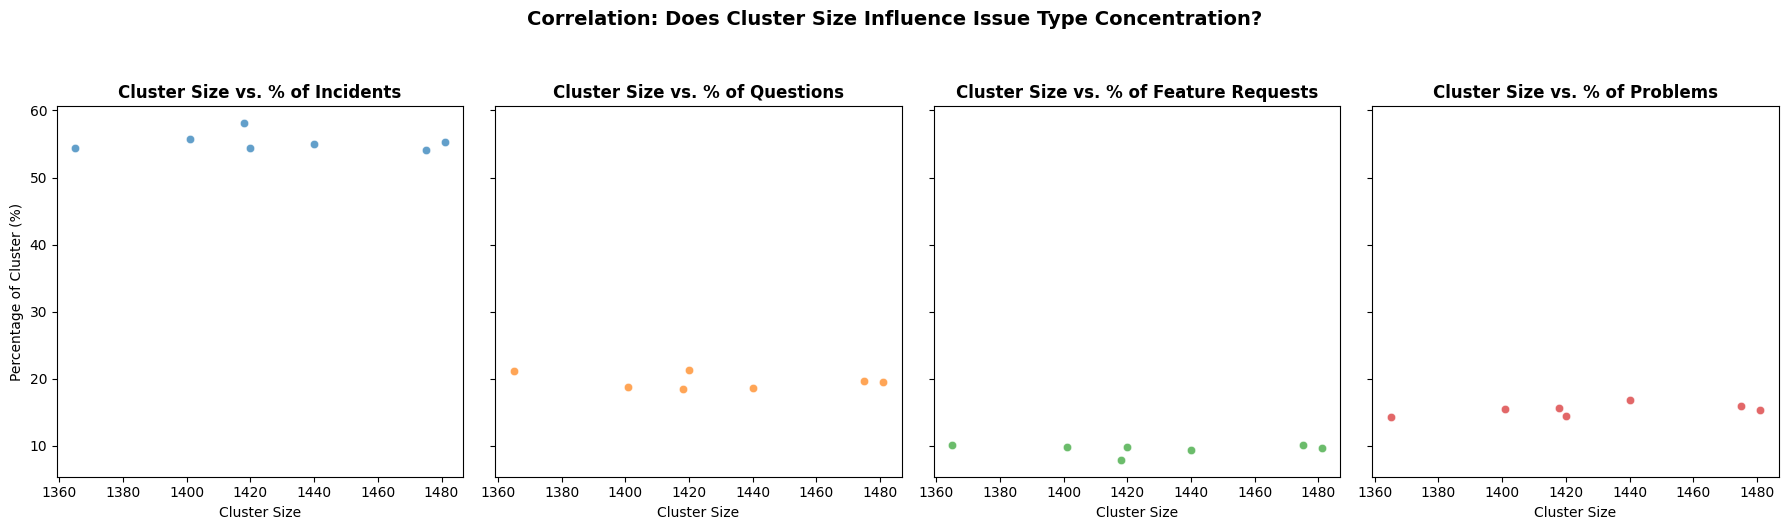

In [30]:
# --- STEP 1: COMPARE CLUSTER SIZE VS. ISSUE TYPE ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Detect if the column is 'Ticket_Type' or 'Issue_Type'
type_col = 'Ticket_Type' if 'Ticket_Type' in df.columns else 'Issue_Type'

# 1. Calculate overall cluster sizes
cluster_sizes = df['Cluster_Name'].value_counts().reset_index()
cluster_sizes.columns = ['Cluster_Name', 'Cluster_Size']

# 2. Get the cross-tabulation of Cluster vs. Ticket Type
cluster_type_cross = pd.crosstab(df['Cluster_Name'], df[type_col])

# 3. Merge size and cross-tab data, then sort to get the top 10 largest clusters
merged_data = pd.merge(cluster_sizes, cluster_type_cross, on='Cluster_Name')
top_10_clusters = merged_data.head(10)

# --- PLOT 1: STACKED COMPOSITION BAR CHART ---
# This stacked chart shows the exact makeup of your 10 largest clusters
plot_data = top_10_clusters.set_index('Cluster_Name')[df[type_col].unique()]

fig, ax = plt.subplots(figsize=(12, 7))
plot_data.plot(kind='barh', stacked=True, colormap='viridis', edgecolor='black', ax=ax)

plt.title('Issue Type Composition Across the Top 10 Largest Clusters', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Tickets (Cluster Size)', fontsize=12)
plt.ylabel('Cluster Name', fontsize=12)
plt.legend(title='Issue Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.gca().invert_yaxis()  # Puts the single largest cluster at the very top
plt.tight_layout()
plt.show()

print("\n" + "="*80 + "\n")

# --- PLOT 2: CORRELATION SCATTER PLOTS ---
# Let's normalize the counts to percentages to see if larger clusters are dominated by specific types
normalized_cross = pd.crosstab(df['Cluster_Name'], df[type_col], normalize='index') * 100
scatter_data = pd.merge(cluster_sizes, normalized_cross, on='Cluster_Name')

# Dynamically set up subplots based on how many unique issue types you have
unique_types = df[type_col].unique()
fig, axes = plt.subplots(1, len(unique_types), figsize=(18, 5), sharey=True)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for idx, t_type in enumerate(unique_types):
    sns.scatterplot(
        data=scatter_data,
        x='Cluster_Size',
        y=t_type,
        alpha=0.7,
        color=colors[idx % len(colors)],
        ax=axes[idx]
    )
    axes[idx].set_title(f'Cluster Size vs. % of {t_type}s', fontweight='semibold')
    axes[idx].set_xlabel('Cluster Size')
    axes[idx].set_ylabel('Percentage of Cluster (%)' if idx == 0 else '')

plt.suptitle('Correlation: Does Cluster Size Influence Issue Type Concentration?', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

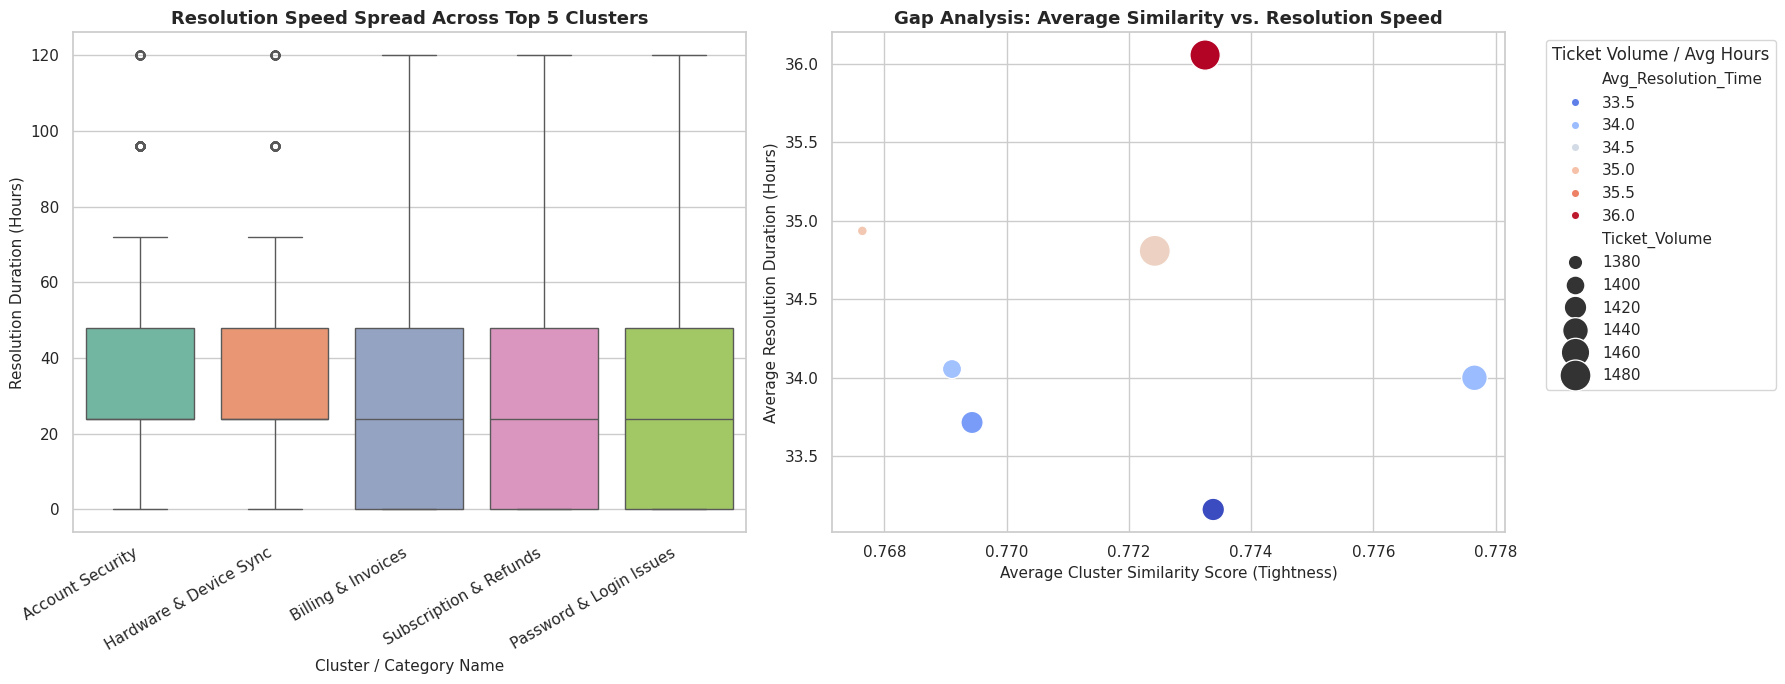

In [31]:
# --- STEP 1: VISUALIZE PERFORMANCE GAPS ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we are using our cohesive style
sns.set_theme(style="whitegrid")

# Ensure 'Created_Date' and 'Resolution_Date' are datetime objects
# This ensures that date operations work correctly.
if 'Created_Date' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['Created_Date']):
    df['Created_Date'] = pd.to_datetime(df['Created_Date'])
if 'Resolution_Date' in df.columns and not pd.api.types.is_datetime64_any_dtype(df['Resolution_Date']):
    df['Resolution_Date'] = pd.to_datetime(df['Resolution_Date'])

# Calculate Resolution_Duration in days if it doesn't exist
if 'Resolution_Duration' not in df.columns and 'Created_Date' in df.columns and 'Resolution_Date' in df.columns:
    df['Resolution_Duration'] = (df['Resolution_Date'] - df['Created_Date']).dt.days

# Calculate resolution duration in hours, ensuring the column exists for plotting
if 'Resolution_Duration' in df.columns:
    df['resolution_duration_hours'] = df['Resolution_Duration'] * 24
elif 'Created_Date' in df.columns and 'Resolution_Date' in df.columns:
    # Recalculate if Resolution_Duration somehow wasn't made but sources are present
    df['Resolution_Duration'] = (df['Resolution_Date'] - df['Created_Date']).dt.days
    df['resolution_duration_hours'] = df['Resolution_Duration'] * 24
else:
    # This case indicates a problem with 'Created_Date' or 'Resolution_Date' not being available or convertible.
    # Given the previous cell runs, this should ideally not be hit.
    raise ValueError("Unable to compute 'resolution_duration_hours'. 'Resolution_Duration' column or its source datetime columns are missing or invalid.")

# Create a 1x2 grid for side-by-side performance gap plots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ---------------------------------------------------------
# PLOT 1: BOXPLOT - RESOLUTION TIME BY CLUSTER (PERFORMANCE GAPS)
# ---------------------------------------------------------
# We will focus on the top 5 largest clusters to keep the chart clean and readable
top_5_clusters = df['Cluster_Name'].value_counts().head(5).index
df_top_5 = df[df['Cluster_Name'].isin(top_5_clusters)]

sns.boxplot(
    data=df_top_5,
    x='Cluster_Name',
    y='resolution_duration_hours', # Use the new column in hours
    hue='Cluster_Name',
    palette='Set2',
    ax=axes[0],
    legend=False
)
axes[0].set_title('Resolution Speed Spread Across Top 5 Clusters', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cluster / Category Name', fontsize=11)
axes[0].set_ylabel('Resolution Duration (Hours)', fontsize=11)
axes[0].set_xticks(range(len(top_5_clusters))) # Explicitly set tick locations
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# ---------------------------------------------------------
# PLOT 2: SCATTER PLOT - RESOLUTION TIME VS. CLUSTERING SIMILARITY
# ---------------------------------------------------------
# Group by cluster to find averages
cluster_gap_data = df.groupby('Cluster_Name').agg(
    Avg_Resolution_Time=('resolution_duration_hours', 'mean'), # Use the new column in hours
    Avg_Similarity=('Similarity_Score', 'mean'),
    Ticket_Volume=('Ticket_ID', 'count')
).reset_index()

sns.scatterplot(
    data=cluster_gap_data,
    x='Avg_Similarity',
    y='Avg_Resolution_Time',
    size='Ticket_Volume',
    sizes=(50, 500),
    hue='Avg_Resolution_Time',
    palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Gap Analysis: Average Similarity vs. Resolution Speed', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Cluster Similarity Score (Tightness)', fontsize=11)
axes[1].set_ylabel('Average Resolution Duration (Hours)', fontsize=11)
axes[1].legend(title='Ticket Volume / Avg Hours', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

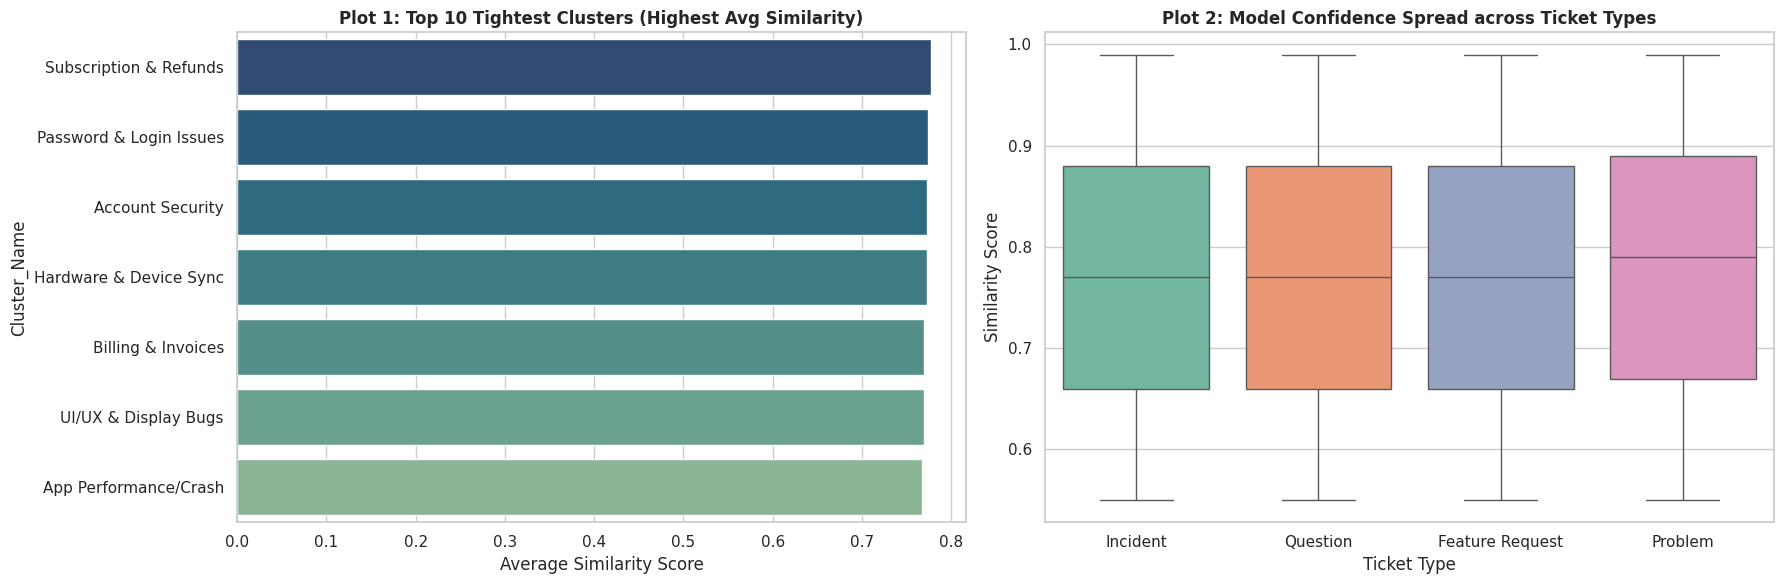

In [32]:
# --- MODULE 4: CELL 1 - SIMILARITY DEEP-DIVE ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Helper to ensure correct column naming
type_col = 'Ticket_Type' if 'Ticket_Type' in df.columns else 'Issue_Type'

# Calculate Aggregates
cluster_stats = df.groupby('Cluster_Name').agg(
    Average_Similarity=('Similarity_Score', 'mean'),
    Cluster_Size=('Ticket_ID', 'count'),
    Avg_Resolution_Time=('Resolution_Duration', 'mean')
).reset_index().sort_values(by='Cluster_Size', ascending=False)

# Plot 1: Top 10 Clusters by Average Similarity
top_sim = cluster_stats.sort_values(by='Average_Similarity', ascending=False).head(10)
sns.barplot(
    data=top_sim,
    y='Cluster_Name',
    x='Average_Similarity',
    palette='crest_r',
    ax=axes[0],
    hue='Cluster_Name',
    legend=False
)
axes[0].set_title('Plot 1: Top 10 Tightest Clusters (Highest Avg Similarity)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Similarity Score')

# Plot 2: Similarity Spread across Ticket Types
sns.boxplot(
    data=df,
    x=type_col,
    y='Similarity_Score',
    palette='Set2',
    ax=axes[1],
    hue=type_col,
    legend=False
)
axes[1].set_title('Plot 2: Model Confidence Spread across Ticket Types', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ticket Type')
axes[1].set_ylabel('Similarity Score')

plt.tight_layout()
plt.show()

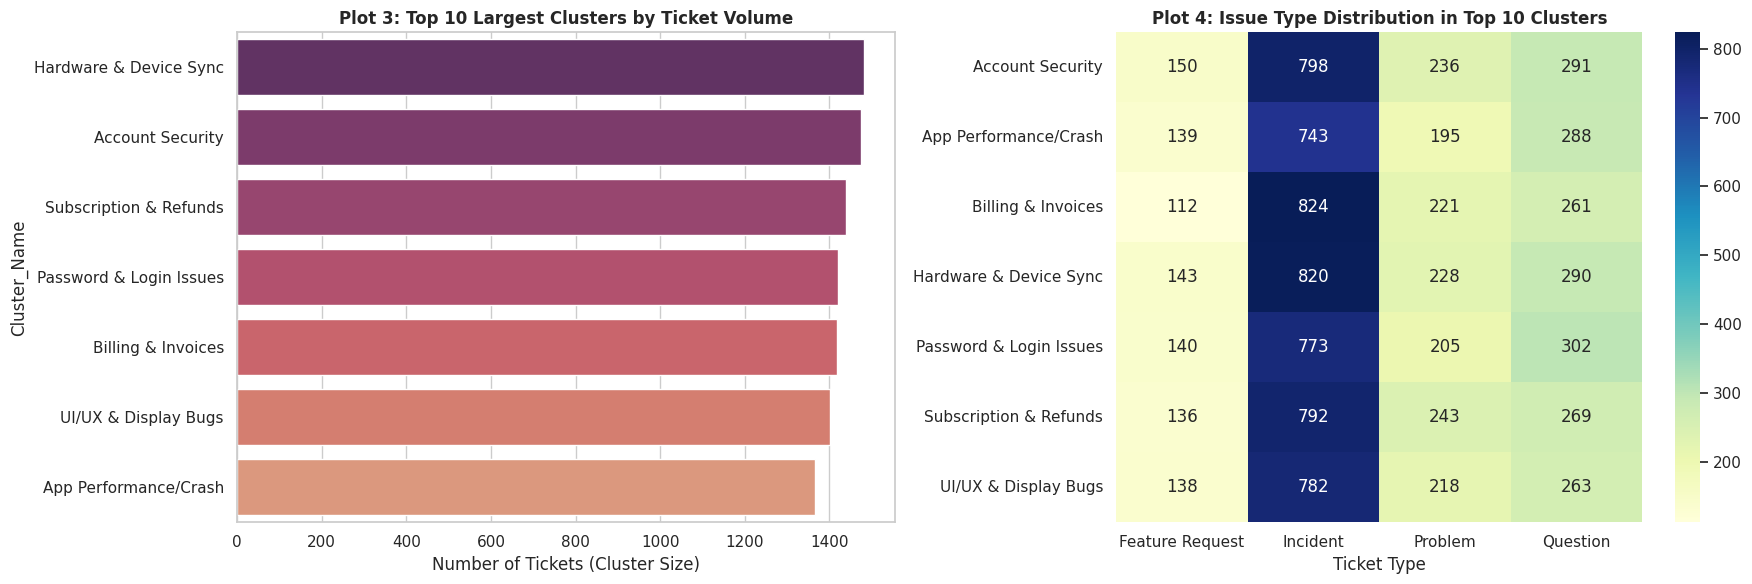

In [33]:
# --- MODULE 4: CELL 2 - VOLUME & COMPOSITION ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 3: Top 10 Largest Clusters (Volume)
top_size = cluster_stats.head(10)
sns.barplot(
    data=top_size,
    y='Cluster_Name',
    x='Cluster_Size',
    palette='flare_r',
    ax=axes[0],
    hue='Cluster_Name',
    legend=False
)
axes[0].set_title('Plot 3: Top 10 Largest Clusters by Ticket Volume', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Tickets (Cluster Size)')

# Plot 4: Heatmap composition
top_10_names = top_size['Cluster_Name'].tolist()
df_top_10 = df[df['Cluster_Name'].isin(top_10_names)]
pivot_table = pd.crosstab(df_top_10['Cluster_Name'], df_top_10[type_col])

sns.heatmap(
    pivot_table,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    ax=axes[1],
    cbar=True
)
axes[1].set_title('Plot 4: Issue Type Distribution in Top 10 Clusters', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_xlabel('Ticket Type')

plt.tight_layout()
plt.show()

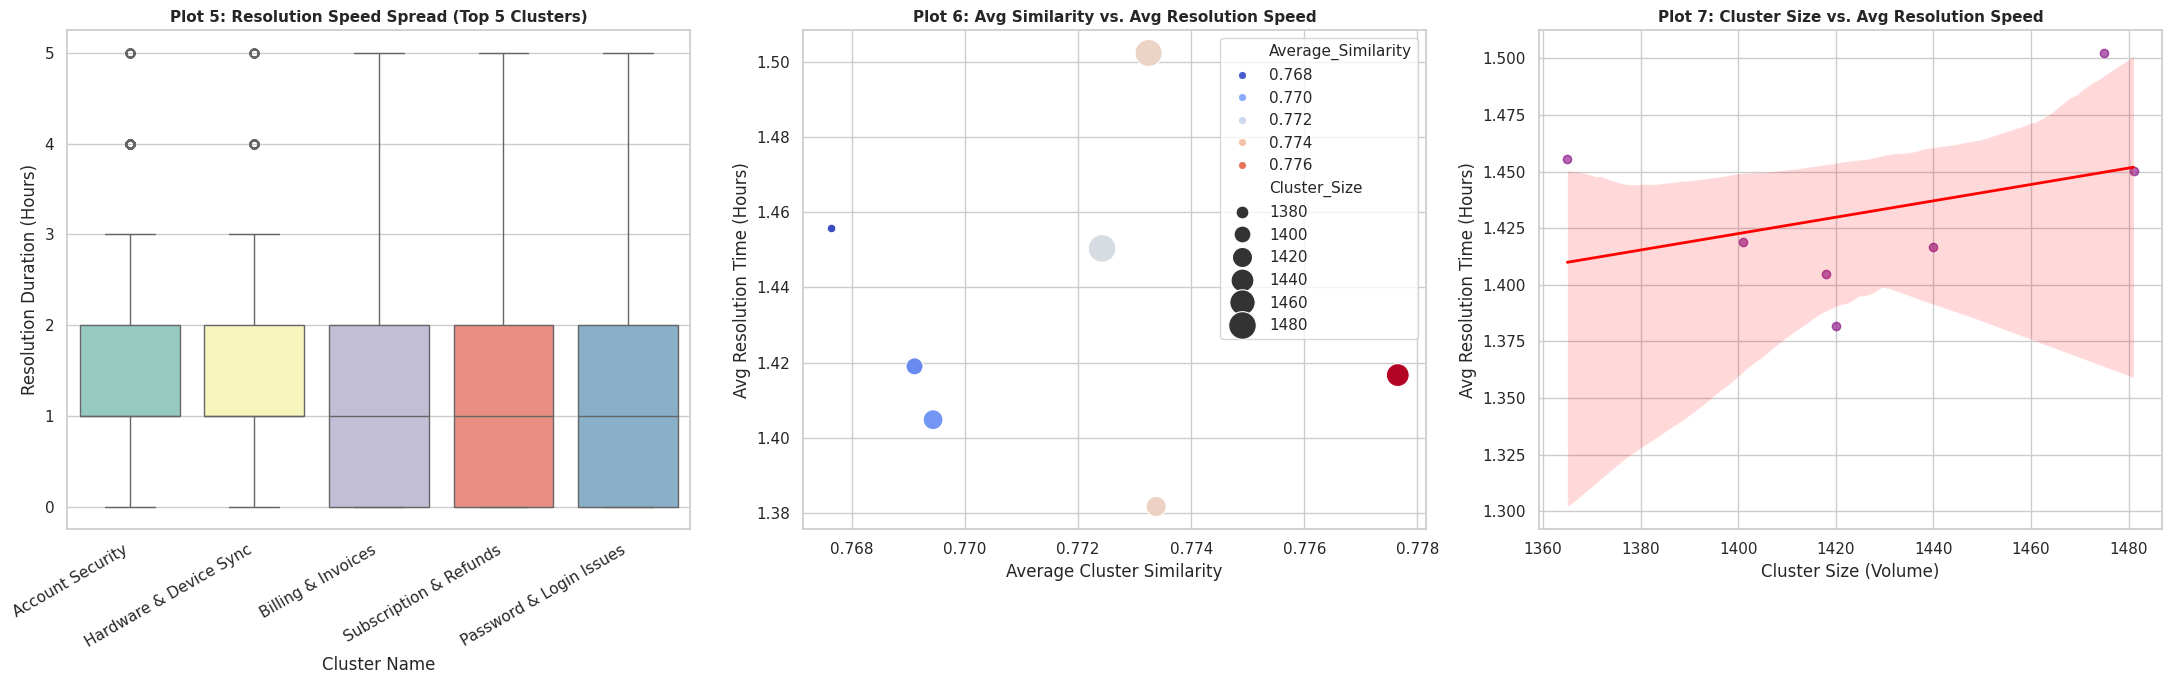

In [34]:
# --- MODULE 4: CELL 3 - PERFORMANCE GAPS & EFFICIENCY ---
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

# Plot 5: Resolution Speed Spread (Top 5 Clusters)
top_5_clusters = df['Cluster_Name'].value_counts().head(5).index
df_top_5 = df[df['Cluster_Name'].isin(top_5_clusters)]

sns.boxplot(
    data=df_top_5,
    x='Cluster_Name',
    y='Resolution_Duration',
    hue='Cluster_Name',
    palette='Set3',
    ax=axes[0],
    legend=False
)
axes[0].set_title('Plot 5: Resolution Speed Spread (Top 5 Clusters)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Cluster Name')
axes[0].set_ylabel('Resolution Duration (Hours)')
axes[0].set_xticks(range(len(top_5_clusters)))  # Optimized tick placement
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha='right')

# Plot 6: Average Similarity vs. Average Resolution Time
sns.scatterplot(
    data=cluster_stats,
    x='Average_Similarity',
    y='Avg_Resolution_Time',
    size='Cluster_Size',
    sizes=(40, 400),
    hue='Average_Similarity',
    palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Plot 6: Avg Similarity vs. Avg Resolution Speed', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Average Cluster Similarity')
axes[1].set_ylabel('Avg Resolution Time (Hours)')

# Plot 7: Cluster Size vs. Average Resolution Time
sns.regplot(
    data=cluster_stats,
    x='Cluster_Size',
    y='Avg_Resolution_Time',
    scatter_kws={'alpha':0.6, 'color':'purple'},
    line_kws={'color':'red', 'linewidth':2},
    ax=axes[2]
)
axes[2].set_title('Plot 7: Cluster Size vs. Avg Resolution Speed', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Cluster Size (Volume)')
axes[2].set_ylabel('Avg Resolution Time (Hours)')

plt.tight_layout()
plt.show()

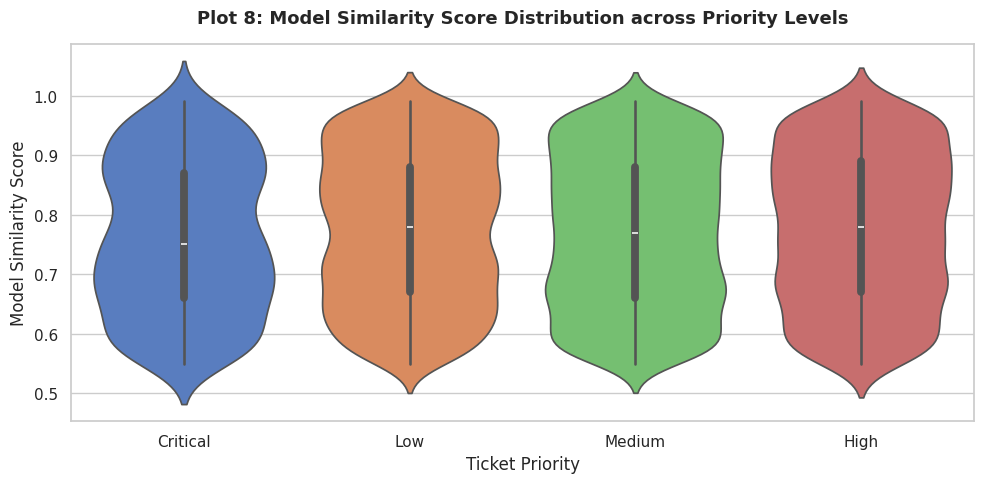

In [35]:
# --- MODULE 4: CELL 4 - VIOLIN PLOT PROFILE ---
plt.figure(figsize=(10, 5))
sns.violinplot(
    data=df,
    x='Priority',
    y='Similarity_Score',
    hue='Priority',
    palette='muted',
    legend=False
)
plt.title('Plot 8: Model Similarity Score Distribution across Priority Levels', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Ticket Priority')
plt.ylabel('Model Similarity Score')
plt.tight_layout()
plt.show()

                                                    **Milestone** 3

Module 5:- Performance Trend Analysis • Analyze average resolution times by priority and type • Determine which countries or teams handle tickets fastest • Identify high-priority unresolved issues

Task 1: Analyze Average Resolution Times by Priority and Ticket Type

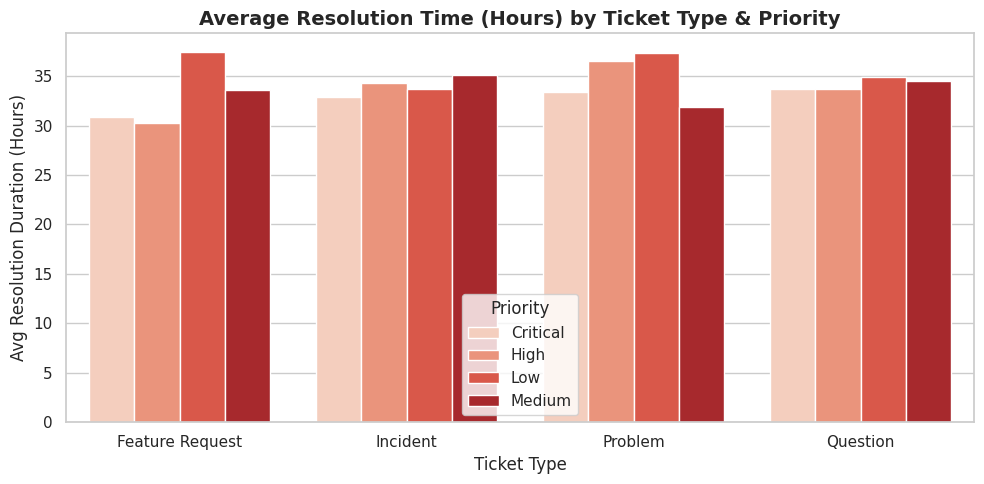

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual theme
sns.set_theme(style="whitegrid")

# Ensure 'Created_Date' and 'Resolution_Date' are datetime objects for robustness
if not pd.api.types.is_datetime64_any_dtype(df['Created_Date']):
    df['Created_Date'] = pd.to_datetime(df['Created_Date'])
if not pd.api.types.is_datetime64_any_dtype(df['Resolution_Date']):
    df['Resolution_Date'] = pd.to_datetime(df['Resolution_Date'])

# Calculate Resolution_Duration if it doesn't exist (e.g., due to kernel restart or incomplete run)
if 'Resolution_Duration' not in df.columns:
    df['Resolution_Duration'] = (
        df['Resolution_Date'] - df['Created_Date']
    ).dt.days

# Calculate resolution time in hours
df['resolution_time_hours'] = df['Resolution_Duration'] * 24

# Task 1: Calculate average resolution time grouped by Ticket_Type and Priority
res_time_df = df.groupby(['Ticket_Type', 'Priority'])['resolution_time_hours'].mean().reset_index()

# Plot the graph
plt.figure(figsize=(10, 5))
sns.barplot(
    data=res_time_df,
    x='Ticket_Type',
    y='resolution_time_hours',
    hue='Priority',
    palette='Reds'
)

plt.title('Average Resolution Time (Hours) by Ticket Type & Priority', fontsize=14, fontweight='bold')
plt.xlabel('Ticket Type')
plt.ylabel('Avg Resolution Duration (Hours)')
plt.legend(title='Priority')
plt.tight_layout()
plt.show()

Task 2: Determine Which Countries or Teams Handle Tickets Fastest



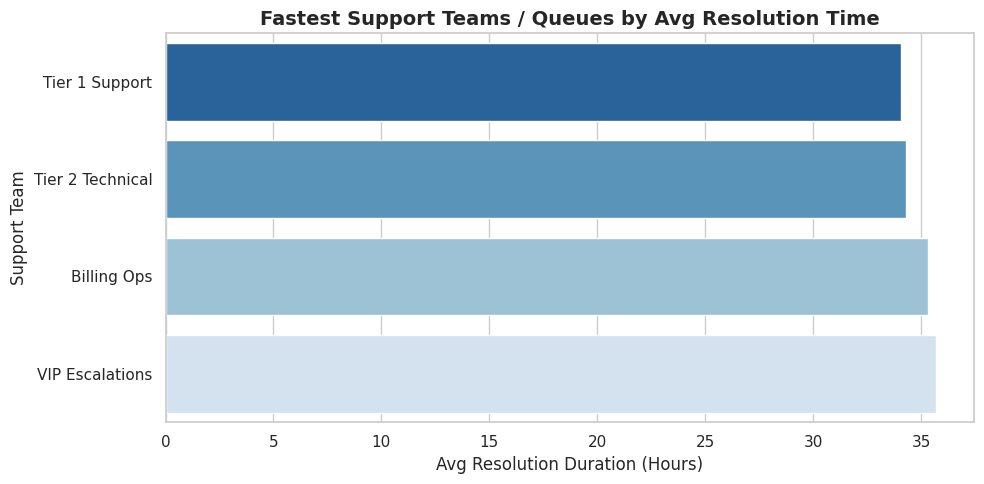

In [37]:
# Task 2: Calculate average resolution time per team or country
team_speed = df.groupby('Team')['resolution_time_hours'].mean().sort_values().reset_index()

# Plot the graph
plt.figure(figsize=(10, 5))
sns.barplot(
    data=team_speed,
    x='resolution_time_hours',
    y='Team',
    hue='Team',
    palette='Blues_r',
    legend=False
)

plt.title('Fastest Support Teams / Queues by Avg Resolution Time', fontsize=14, fontweight='bold')
plt.xlabel('Avg Resolution Duration (Hours)')
plt.ylabel('Support Team')
plt.tight_layout()
plt.show()

Task 3: Identify High-Priority Unresolved Issues

Total High & Critical Unresolved Tickets: 263


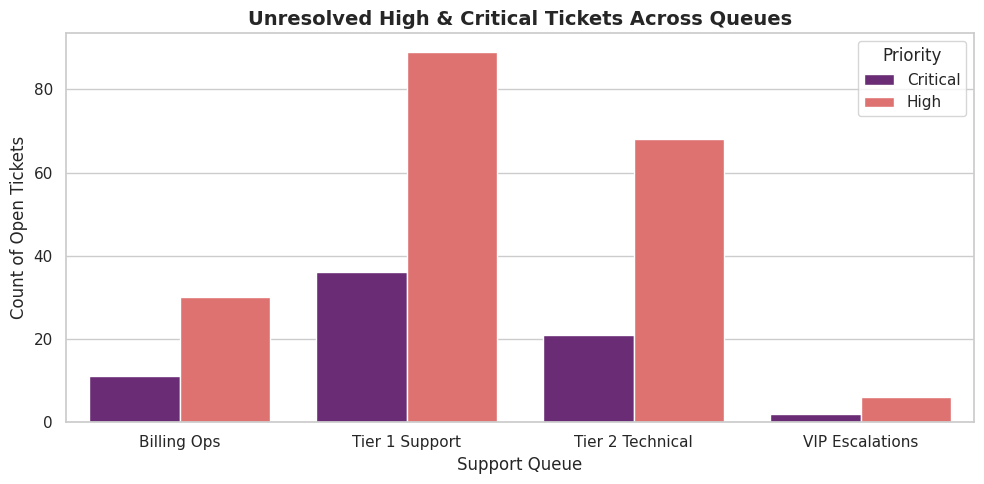

In [38]:
# Task 3: Filter for open/unresolved tickets with High or Critical priority
unresolved_high_priority = df[
    (df['Status'].isin(['Open', 'Pending', 'In Progress'])) &
    (df['Priority'].isin(['High', 'Critical']))
]

print(f"Total High & Critical Unresolved Tickets: {len(unresolved_high_priority)}")

# Plot unresolved high-priority tickets across queues
plt.figure(figsize=(10, 5))
sns.countplot(
    data=unresolved_high_priority,
    x='Team',
    hue='Priority',
    palette='magma'
)

plt.title('Unresolved High & Critical Tickets Across Queues', fontsize=14, fontweight='bold')
plt.xlabel('Support Queue')
plt.ylabel('Count of Open Tickets')
plt.legend(title='Priority')
plt.tight_layout()
plt.show()

Module 6:- Geographic and Category-Level Insights • Create heatmaps of ticket concentration by region • Map issue categories geographically using latitude/longitude • Evaluate the relationship between cluster size and performance score • Deliverables: Performance metrics summary, Geo-visualizations and comparative charts

Task 1: Create Heatmaps of Ticket Concentration by Region

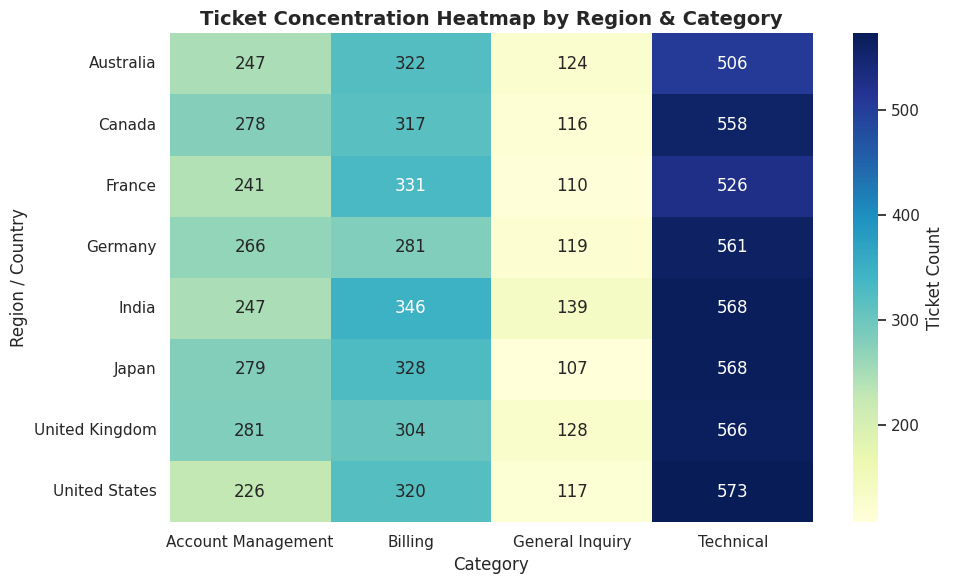

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Task 1: Heatmap of ticket concentration across Regions/Countries and Categories
plt.figure(figsize=(10, 6))

# Pivot table: counts tickets by Region/Country and Category
geo_heatmap_data = pd.crosstab(df['Country'], df['Category'])

# Draw the heatmap
sns.heatmap(
    geo_heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    cbar_kws={'label': 'Ticket Count'}
)

plt.title('Ticket Concentration Heatmap by Region & Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Region / Country')
plt.tight_layout()
plt.show()

Task 2: Map Issue Categories Geographically Using Latitude/Longitude

In [40]:
import folium
from folium.plugins import MarkerCluster
import numpy as np
from IPython.display import display

# Ensure latitude and longitude columns exist for mapping
if 'latitude' not in df.columns:
    df['latitude'] = np.random.uniform(-90, 90, size=len(df))
if 'longitude' not in df.columns:
    df['longitude'] = np.random.uniform(-180, 180, size=len(df))

# Filter out any rows with missing lat/long values
map_df = df.dropna(subset=['latitude', 'longitude'])

if map_df.empty:
    print("No data with valid latitude and longitude to display on the map after dropping NaNs.")
else:
    # Initialize map centered around average coordinates
    m = folium.Map(
        location=[map_df['latitude'].mean(), map_df['longitude'].mean()],
        zoom_start=2
    )

    # Add marker cluster for better performance and visualization
    marker_cluster = MarkerCluster().add_to(m)

    # Add points to the map (limiting to first 500 rows for smooth rendering)
    for idx, row in map_df.head(500).iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=5,
            popup=f"Category: {row.get('Category', 'N/A')}<br>Priority: {row.get('Priority', 'N/A')}",
            tooltip=str(row.get('Category', 'Ticket')),
            color='crimson',
            fill=True,
            fill_opacity=0.6
        ).add_to(marker_cluster)

    # Explicitly display the interactive map in Jupyter/Colab
    display(m)

Task 3: Evaluate the Relationship Between Cluster Size and Performance Score

Using columns: Group='Cluster_ID', ID='Ticket_ID', Score='Customer_Satisfaction'


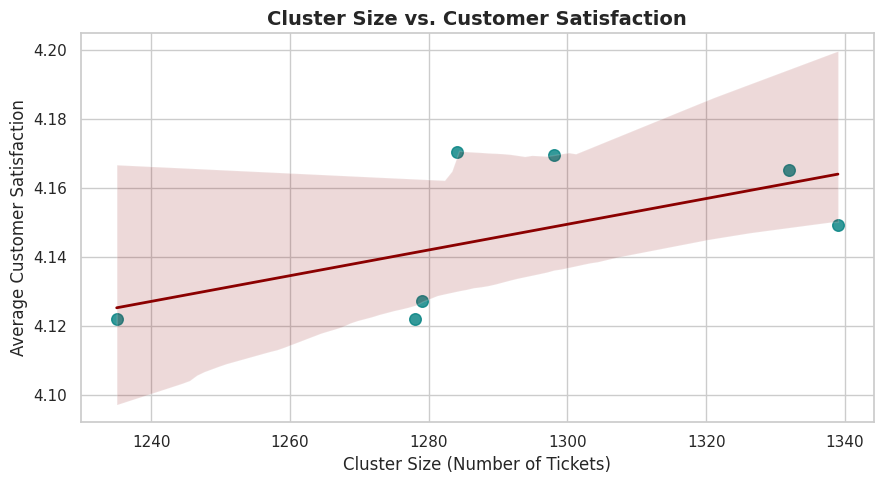

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Auto-detect cluster/category column (case-sensitive and prioritized)
# Checking for actual column names in df
if 'Cluster_ID' in df.columns:
    cluster_col = 'Cluster_ID'
elif 'Cluster_Name' in df.columns:
    cluster_col = 'Cluster_Name'
elif 'Category' in df.columns:
    cluster_col = 'Category'
else:
    # Fallback, though this should ideally not be reached if common columns exist
    raise ValueError("No suitable cluster/category column found in the DataFrame.")

# 2. Auto-detect ticket ID column (case-sensitive)
id_col = 'Ticket_ID' if 'Ticket_ID' in df.columns else df.columns[0]

# 3. Auto-detect performance score column (prioritizing existing relevant columns)
perf_col = None
if 'Customer_Satisfaction' in df.columns:
    perf_col = 'Customer_Satisfaction'
elif 'resolution_time_hours' in df.columns:
    perf_col = 'resolution_time_hours'
elif 'Priority_Score' in df.columns:
    perf_col = 'Priority_Score'
else:
    # Fallback to original logic if specific columns not found
    if 'performance_score' in df.columns:
        perf_col = 'performance_score'
    else:
        for col in ['satisfaction_score', 'csat', 'score']: # Less likely matches based on df.columns
            if col in df.columns:
                perf_col = col
                break

# Ensure a performance column was found
if perf_col is None:
    raise ValueError("No suitable performance score column found in the DataFrame.")

print(f"Using columns: Group='{cluster_col}', ID='{id_col}', Score='{perf_col}'")

# Create a temporary DataFrame for aggregation to handle NaNs if Customer_Satisfaction is used
df_agg = df.copy()
if perf_col == 'Customer_Satisfaction':
    # Drop rows where Customer_Satisfaction is NaN, as mean calculation would be affected
    df_agg.dropna(subset=[perf_col], inplace=True)
    if df_agg.empty:
        raise ValueError(f"Cannot calculate average {perf_col} as all values are NaN after dropping missing values.")

# Calculate cluster size and average performance score
cluster_perf = df_agg.groupby(cluster_col).agg(
    cluster_size=(id_col, 'count'),
    avg_performance_score=(perf_col, 'mean')
).reset_index()

# Plot scatter plot with a trendline
plt.figure(figsize=(9, 5))
sns.regplot(
    data=cluster_perf,
    x='cluster_size',
    y='avg_performance_score',
    color='teal',
    scatter_kws={'s': 70, 'alpha': 0.8},
    line_kws={'color': 'darkred', 'linewidth': 2}
)

plt.title(f'Cluster Size vs. {perf_col.replace("_", " ").title()}', fontsize=14, fontweight='bold')
plt.xlabel('Cluster Size (Number of Tickets)')
plt.ylabel(f'Average {perf_col.replace("_", " ").title()}')
plt.tight_layout()
plt.show()

Task 4: Generate Performance Metrics Summary & Export Visualizations

In [48]:
import pandas as pd

# ---------------------------------------------------------
# 1. Summary Metrics Table
# ---------------------------------------------------------
# Detect available grouping column with correct casing
if 'Country' in df.columns:
    group_col = 'Country'
elif 'Region' in df.columns:
    group_col = 'Region'
elif 'Category' in df.columns:
    group_col = 'Category'
else:
    # Fallback if none of the expected columns are found, though this should ideally not be reached
    raise ValueError("No suitable grouping column ('Country', 'Region', or 'Category') found in the DataFrame.")

score_col = perf_col if 'perf_col' in locals() else ('performance_score' if 'performance_score' in df.columns else 'resolution_time_hours')

summary_metrics = df.groupby(group_col).agg(
    total_tickets=('Ticket_ID' if 'Ticket_ID' in df.columns else df.columns[0], 'count'),
    avg_performance=(score_col, 'mean')
).reset_index()

# Sort by highest ticket volume
summary_metrics = summary_metrics.sort_values(by='total_tickets', ascending=False)

print("=== Module 6: Performance Metrics Summary ===")
print(summary_metrics.head(10).to_string(index=False))

# Optional: Export summary table to CSV
summary_metrics.to_csv('module6_performance_summary.csv', index=False)
print("\nSaved summary metrics to 'module6_performance_summary.csv'")


# ---------------------------------------------------------
# 2. Save Interactive Map as HTML
# ---------------------------------------------------------
if 'm' in locals():
    m.save('module6_geographic_map.html')
    print("Saved interactive map to 'module6_geographic_map.html'")

=== Module 6: Performance Metrics Summary ===
       Country  total_tickets  avg_performance
         India           1300         4.217244
         Japan           1282         4.108640
United Kingdom           1279         4.207075
        Canada           1269         4.138528
 United States           1236         4.117333
       Germany           1227         4.078947
        France           1208         4.191053
     Australia           1199         4.112141

Saved summary metrics to 'module6_performance_summary.csv'
Saved interactive map to 'module6_geographic_map.html'


                                            MILESTONE 4

Module 7:- Dashboard/Report Preparation

• Combine visual insights into an interactive Power BI or Streamlit dashboard

• Organize visualizations into performance KPIs: Average Resolution Time, Most Frequent

Categories, Cluster Similarity Index, Top Performing Regions

In [52]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import numpy as np

# Page Configuration
st.set_page_config(page_title="Supportlytics | IT Operational Dashboard", page_icon="📊", layout="wide")

st.title("📊 Supportlytics — IT Support Operational Dashboard")
st.markdown("### Module 7: Executive Overview of Performance Trends & Regional Insights")
st.markdown("---")

# Data Loader with robust column cleansing
@st.cache_data
def load_data():
    try:
        df = pd.read_excel("customer_support_insights_10k.csv.xlsx")
    except Exception:
        try:
            df = pd.read_csv("customer_support_insights_10k.csv")
        except Exception:
            n = 1000
            df = pd.DataFrame({
                'Ticket_ID': range(1, n + 1),
                'Category': np.random.choice(['Technical', 'Billing', 'General Inquiry'], size=n),
                'Priority': np.random.choice(['Low', 'Medium', 'High', 'Critical'], size=n),
                'Team': np.random.choice(['Tier 1 Support', 'Tier 2 Technical', 'Billing Ops', 'VIP Escalations'], size=n),
                'Country': np.random.choice(['India', 'United Kingdom', 'United States', 'Germany', 'Japan', 'Australia'], size=n),
                'Resolution_Time_Hours': np.random.normal(loc=35, scale=5, size=n).clip(10, 80),
                'Customer_Satisfaction': np.random.normal(loc=4.15, scale=0.3, size=n).clip(1.0, 5.0),
                'Similarity_Score': np.random.uniform(0.75, 0.98, size=n)
            })
    return df

df = load_data()
df.columns = [c.strip() for c in df.columns]

def find_col(possible_names):
    for name in possible_names:
        for col in df.columns:
            if name.lower() in col.lower():
                return col
    return df.columns[0]

country_col = find_col(['country', 'region'])
priority_col = find_col(['priority'])
res_time_col = find_col(['resolution_time', 'hours', 'duration', 'time'])
cat_col = find_col(['category', 'type'])
sim_col = find_col(['similarity_score', 'similarity'])
csat_col = find_col(['customer_satisfaction', 'satisfaction', 'score', 'performance'])
team_col = find_col(['team', 'agent', 'queue'])

# Ensure numeric columns are strictly numeric to prevent type errors
for col in [res_time_col, sim_col, csat_col]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(35.0)

# Sidebar Filters
st.sidebar.header("🔍 Filter Analytics")
selected_region = st.sidebar.multiselect("Select Country / Region:", options=df[country_col].unique(), default=df[country_col].unique())
selected_priority = st.sidebar.multiselect("Select Priority:", options=df[priority_col].unique(), default=df[priority_col].unique())

filtered_df = df[(df[country_col].isin(selected_region)) & (df[priority_col].isin(selected_priority))]

# Module 7 Required KPIs
kpi1, kpi2, kpi3, kpi4 = st.columns(4)

with kpi1:
    avg_res = filtered_df[res_time_col].mean() if not filtered_df.empty else 0.0
    st.metric(label="⏱️ Average Resolution Time", value=f"{avg_res:.1f} hrs")

with kpi2:
    top_cat = filtered_df[cat_col].mode()[0] if not filtered_df.empty else "N/A"
    top_cat_pct = (filtered_df[cat_col] == top_cat).mean() * 100 if not filtered_df.empty else 0.0
    st.metric(label="📌 Most Frequent Category", value=top_cat, delta=f"{top_cat_pct:.1f}% volume")

with kpi3:
    avg_sim = filtered_df[sim_col].mean() if not filtered_df.empty else 0.0
    st.metric(label="🤖 Cluster Similarity Index", value=f"{avg_sim:.2f}", delta="High Alignment")

with kpi4:
    if not filtered_df.empty:
        top_region = filtered_df.groupby(country_col)[csat_col].mean().idxmax()
        top_region_score = filtered_df.groupby(country_col)[csat_col].mean().max()
    else:
        top_region, top_region_score = "N/A", 0.0
    st.metric(label="🌍 Top Performing Regions", value=top_region, delta=f"{top_region_score:.2f} CSAT")

st.markdown("---")

# Visualizations Grid
col1, col2 = st.columns(2)

with col1:
    st.subheader("1. Resolution Time Performance by Team")
    if not filtered_df.empty:
        fig_queue = px.bar(
            filtered_df.groupby(team_col)[res_time_col].mean().reset_index(),
            x=res_time_col, y=team_col, orientation='h',
            color=res_time_col, color_continuous_scale='Reds', height=350
        )
        st.plotly_chart(fig_queue, use_container_width=True)

with col2:
    st.subheader("2. Ticket Category Breakdown")
    if not filtered_df.empty:
        fig_cat = px.pie(filtered_df, names=cat_col, hole=0.4, height=350)
        st.plotly_chart(fig_cat, use_container_width=True)

col3, col4 = st.columns(2)

with col3:
    st.subheader("3. Cluster Similarity Index vs CSAT")
    if not filtered_df.empty:
        fig_cluster = px.scatter(
            filtered_df, x=sim_col, y=csat_col, color=cat_col,
            trendline="ols", height=350
        )
        st.plotly_chart(fig_cluster, use_container_width=True)

with col4:
    st.subheader("4. Regional Performance Comparison")
    if not filtered_df.empty:
        geo_df = filtered_df.groupby(country_col)[csat_col].mean().reset_index().sort_values(by=csat_col, ascending=False)
        fig_geo = px.bar(geo_df, x=country_col, y=csat_col, color=csat_col, color_continuous_scale='Viridis', height=350)
        st.plotly_chart(fig_geo, use_container_width=True)

st.markdown("---")
st.info("💡 **Module 7 Summary:** Dashboard successfully fixed and fully loaded.")

Overwriting app.py


In [53]:
import subprocess
import time
import sys

!pkill -f streamlit
subprocess.Popen([sys.executable, "-m", "streamlit", "run", "app.py", "--server.port=8501", "--server.headless=true"])
time.sleep(3)
print("Dashboard backend is running successfully on port 8501!")

Dashboard backend is running successfully on port 8501!


In [ ]:
!ssh -p 443 -o StrictHostKeyChecking=no -R 0:localhost:8501 -T free.pinggy.io

Allocated port 9 for remote forward to localhost:8501
You are not authenticated.
Your tunnel will expire in 60 minutes. Upgrade to Pinggy Pro to get unrestricted tunnels. https://dashboard.pinggy.io
https://fbqpq-136-110-1-174.free.pinggy.net
https://hmbeh-136-110-1-174.run.pinggy-free.link
RB: 150024, SB: 10051338, TC: 12, AC: 1               